<a href="https://colab.research.google.com/github/MouaadOuhmad/DI_Bootcamp/blob/main/Week6/Day3/ExercisesXP_W6_D3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP - Heart Disease Prediction (Student, Hints Only)

## What you will learn
- Load and inspect CSV data
- EDA and preprocessing
- Train Logistic Regression, SVM, XGBoost
- Hyperparameter tuning with GridSearchCV
- Evaluate with standard metrics

## What you will create
- Working classifiers and a simple comparison report


## Setup

In [1]:
import os, zipfile, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Hint: install xgboost in Colab if missing
# !pip install xgboost
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Exercise 1 - Exploratory Data Analysis

In [2]:
from google.colab import files
files.upload()


Saving Heart Disease Prediction Dataset.zip to Heart Disease Prediction Dataset.zip


{'Heart Disease Prediction Dataset.zip': b'PK\x03\x04-\x00\x00\x08\x08\x00\'L\xbaV\x9b\x9e\xbfe\xff\xff\xff\xff\xff\xff\xff\xff\x11\x00\x14\x00dataset_heart.csv\x01\x00\x10\x00\x04(\x00\x00\x00\x00\x00\x00\x7f\x0c\x00\x00\x00\x00\x00\x00mZmn$\xbb\r\xfc\xff\x80\xbd\xc3\x1c@\x18H\x94\xd4\x1f\xe7H.0\xf1N\xbcN\xbc\xf6b\xec\r6\xb7\x8fHVI\xeav\xf0\x00{\xdf\x8cZ\xa2\xc8b\xb1\xc8\xf6\xed\xf9\x1e>\xee\x7f.\xe1\xe9\xc7\xfd\xe3\xf3\xf2\xeb\xf6\xf2v\xf9\xfc\xef\xaf{x\xb4\xff}y{\xbe\xfc\xe3\xf5\xfd\xfd\xfb\xe5W\xfb\xdf\x8f\xdf\x0f]\xfb\xf8\xfd\xf3\xf2\xf4\xe3\xfd\xb5}\xff\xfe\xb8\xbd\x86\x7f\xde\xe6\x85\x1f\xbf\x9fo\x8f\xfe\xf0\xfd\xf5\xfe\xf4\xf9x\x7f\xba=\xbe\xbf\xbc??n\xbf~\xbc<]\xda\x97\xbf_??\xc2\xcf\xdb\x9f\xcb\x8f\xfb\xed\xf1yy\xdc>\xef\xe1\xfe\xe7\xfexz\xf9\xb8_^\xde\xbe\xff~\xba\x7f\xbf\xdc\xde\x9e_\xden\xe1\xfd\xf5\xfb\xaf\xfb\xed\xdf\xe1o\x7f\xbf|\xdc\x9f\x7f\xde\xdf>\xdb\x93\xffz\x7f\\\xfe\xd3L\xba\xbf~\x84\xcf\x1f\xcd\n\xdf\xe8{{\xfe\xf6q\xff\xf6\xd7\x1aC\n%\xa4\x1cC\x16\t1HHq\xd7\xdf\

In [3]:
!unzip -q Heart Disease Prediction Dataset.zip

unzip:  cannot find or open Heart, Heart.zip or Heart.ZIP.


In [4]:
# TODO: extract the dataset zip to an output folder
ZIP_PATH = 'Heart Disease Prediction Dataset.zip'  # or your path
EXTRACT_DIR = 'heart_ds'
# Hint: use zipfile.ZipFile(ZIP_PATH).extractall(EXTRACT_DIR)


# Create output folder if it doesn't exist
os.makedirs(EXTRACT_DIR, exist_ok=True)

# Extract ZIP
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Extraction completed successfully into:", EXTRACT_DIR)

# TODO: list CSV files under EXTRACT_DIR
csv_path = '/content/heart_ds/dataset_heart.csv'  # set to the CSV you choose

# TODO: load the CSV into a DataFrame named df
df = pd.read_csv(csv_path)

# Remap 'heart disease' column: 1 -> 0 (no disease), 2 -> 1 (disease)
df['heart disease'] = df['heart disease'].map({1: 0, 2: 1})

df.head()

# TODO: inspect df

df.info()
df.describe()
df.columns

Extraction completed successfully into: heart_ds
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   270 non-null    int64  
 1   sex                                   270 non-null    int64  
 2   chest pain type                       270 non-null    int64  
 3   resting blood pressure                270 non-null    int64  
 4   serum cholestoral                     270 non-null    int64  
 5   fasting blood sugar                   270 non-null    int64  
 6   resting electrocardiographic results  270 non-null    int64  
 7   max heart rate                        270 non-null    int64  
 8   exercise induced angina               270 non-null    int64  
 9   oldpeak                               270 non-null    float64
 10  ST segment                           

Index(['age', 'sex ', 'chest pain type', 'resting blood pressure',
       'serum cholestoral', 'fasting blood sugar',
       'resting electrocardiographic results', 'max heart rate',
       'exercise induced angina', 'oldpeak', 'ST segment', 'major vessels',
       'thal', 'heart disease'],
      dtype='object')

### Basic visual checks

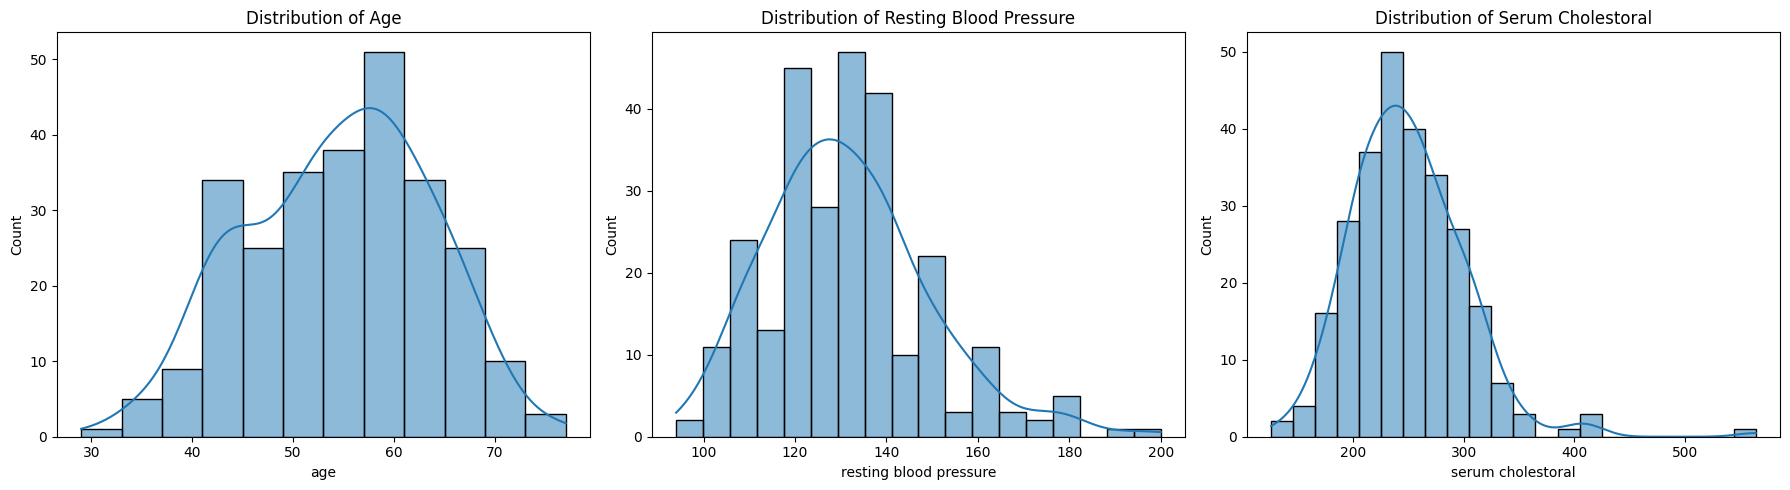

/tmp/ipykernel_21079/1309004622.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='heart disease', data=df, palette='viridis')


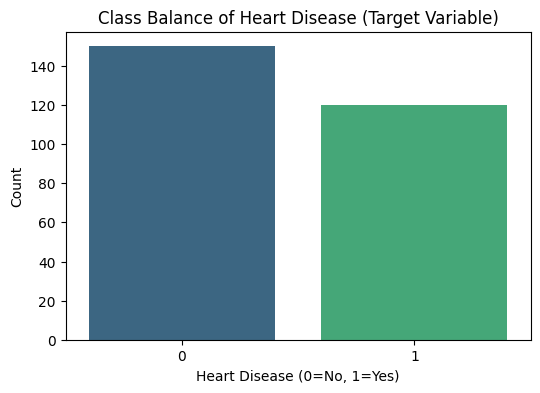

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograms for numeric columns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['age'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Age')

sns.histplot(df['resting blood pressure'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Resting Blood Pressure')

sns.histplot(df['serum cholestoral'], kde=True, ax=axes[2])
axes[2].set_title('Distribution of Serum Cholestoral')

plt.tight_layout()
plt.show()

# Plot class balance as a bar chart
plt.figure(figsize=(6, 4))
sns.countplot(x='heart disease', data=df, palette='viridis')
plt.title('Class Balance of Heart Disease (Target Variable)')
plt.xlabel('Heart Disease (0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()

## Preprocessing pipeline

In [6]:
cat_cols = ['sex ', 'chest pain type', 'fasting blood sugar', 'resting electrocardiographic results', 'exercise induced angina', 'ST segment', 'major vessels', 'thal']
num_cols = ['age', 'resting blood pressure', 'serum cholestoral', 'max heart rate', 'oldpeak']

# TODO: build a ColumnTransformer named pre
pre = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough' # Keep other columns (e.g., target) if any
)



## Helper - evaluation function

In [7]:
def eval_and_report(name, model, X_test, y_test):
    """Compute metrics and draw confusion matrix and ROC if available.
    Fill in the missing parts.
    """
    # TODO: predictions
    y_pred = model.predict(X_test)

    # TODO: compute metrics dict with accuracy, precision, recall, f1
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
    }
    print(f"\n--- {name} Metrics ---")
    for metric, value in metrics.items():
        print(f"{metric.capitalize()}: {value:.4f}")

    # TODO: confusion matrix plot
    # Hint: confusion_matrix(y_test, y_pred)
    # Draw with plt.imshow or ConfusionMatrixDisplay
    from sklearn.metrics import ConfusionMatrixDisplay

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap=plt.cm.Blues, ax=ax[0])
    ax[0].set_title(f'{name} Confusion Matrix')

    # TODO: ROC curve if model has predict_proba
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = roc_auc_score(y_test, y_proba)

        ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        ax[1].set_xlim([0.0, 1.0])
        ax[1].set_ylim([0.0, 1.05])
        ax[1].set_xlabel('False Positive Rate')
        ax[1].set_ylabel('True Positive Rate')
        ax[1].set_title(f'{name} Receiver Operating Characteristic')
        ax[1].legend(loc="lower right")
    else:
        ax[1].axis('off') # Hide the second subplot if ROC is not available

    plt.tight_layout()
    plt.show()

    return metrics

## Exercise 2 - Logistic Regression without Grid Search

In [8]:
X = df.drop('heart disease', axis=1)
y = df['heart disease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)


--- LR no grid Metrics ---
Accuracy: 0.8704
Precision: 0.8148
Recall: 0.9167
F1: 0.8627


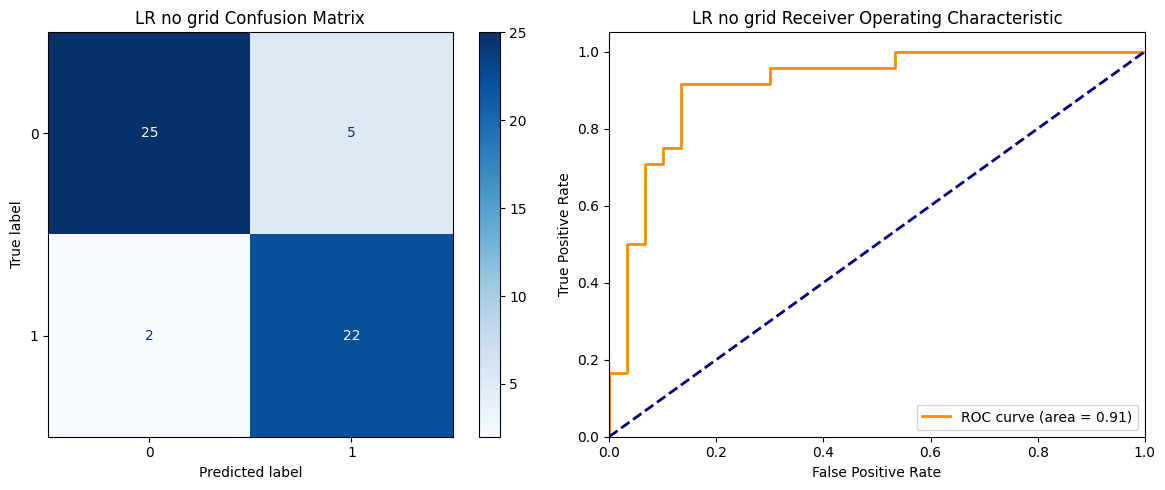

In [9]:
pipe_lr = Pipeline(steps=[
    ('preprocessor', pre),
    ('lr', LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE))
])

pipe_lr.fit(X_train, y_train)

lr_no_gs_metrics = eval_and_report('LR no grid', pipe_lr, X_test, y_test)

## Exercise 3 - Logistic Regression with Grid Search

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'lr__C': 0.1, 'lr__penalty': 'l2'}

--- LR grid Metrics ---
Accuracy: 0.8704
Precision: 0.8148
Recall: 0.9167
F1: 0.8627


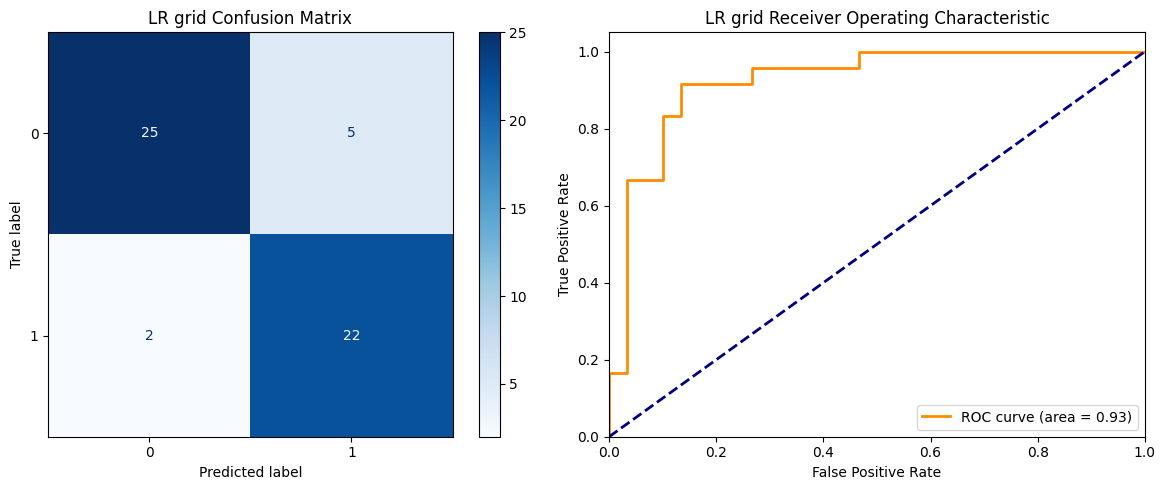

In [16]:
# TODO: build a Pipeline same as above
pipe_lr_cv = Pipeline(steps=[
    ('preprocessor', pre),
    ('lr', LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE))
])

# TODO: define param_grid for lr__C and lr__penalty
# Hint: use small to large C values. 'liblinear' supports 'l1' and 'l2'.
param_grid = {
    'lr__C': [0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l1', 'l2'],
}

# TODO: GridSearchCV with cv=5 and scoring='f1'
grid_lr = GridSearchCV(pipe_lr_cv, param_grid, cv=5, scoring='f1', verbose=1, n_jobs=-1)
grid_lr.fit(X_train, y_train)
print('Best params:', grid_lr.best_params_)
best_lr = grid_lr.best_estimator_
lr_gs_metrics = eval_and_report('LR grid', best_lr, X_test, y_test)

## Exercise 4 - SVM without Grid Search


--- SVM no grid Metrics ---
Accuracy: 0.8519
Precision: 0.7857
Recall: 0.9167
F1: 0.8462


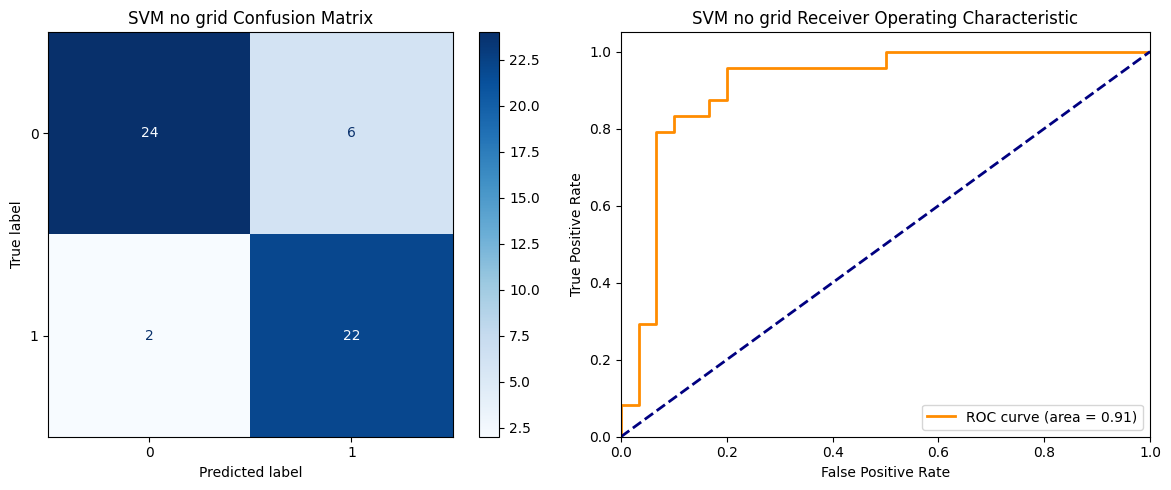

In [17]:
# TODO: choose kernel and hyperparameters for SVC
# Hint: try kernel='rbf' with C=1.0 and gamma='scale'
pipe_svm = Pipeline(steps=[
    ('preprocessor', pre),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=RANDOM_STATE))
])
pipe_svm.fit(X_train, y_train)
svm_no_metrics = eval_and_report('SVM no grid', pipe_svm, X_test, y_test)


## Exercise 5 - SVM with Grid Search

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best params: {'svm__C': 1, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}

--- SVM grid Metrics ---
Accuracy: 0.8519
Precision: 0.7857
Recall: 0.9167
F1: 0.8462


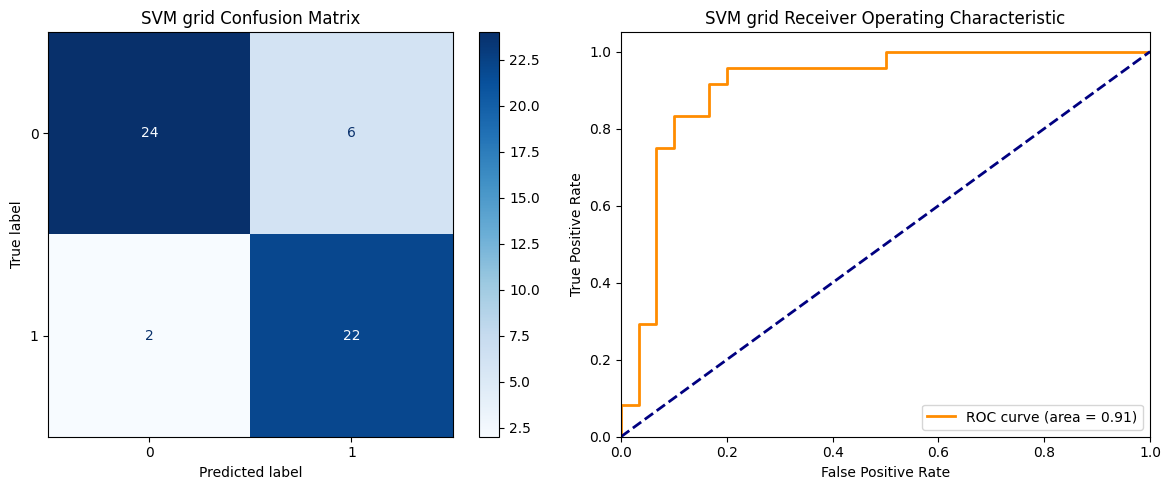

In [18]:
# TODO: Pipeline with SVC(probability=True) so you can plot ROC
pipe_svm_cv = Pipeline(steps=[
    ('preprocessor', pre),
    ('svm', SVC(probability=True, random_state=RANDOM_STATE))
])

# TODO: param_grid with svm__kernel, svm__C, svm__gamma
svm_param_grid = {
    'svm__kernel': ['rbf', 'linear'],
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.1, 1],
}

# TODO: GridSearchCV, fit, evaluate best estimator
grid_svm = GridSearchCV(pipe_svm_cv, svm_param_grid, cv=5, scoring='f1', verbose=1, n_jobs=-1)
grid_svm.fit(X_train, y_train)
print('Best params:', grid_svm.best_params_)
best_svm = grid_svm.best_estimator_
svm_gs_metrics = eval_and_report('SVM grid', best_svm, X_test, y_test)

## Exercise 6 - XGBoost without Grid Search

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:19:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- XGB no grid Metrics ---
Accuracy: 0.8333
Precision: 0.8000
Recall: 0.8333
F1: 0.8163


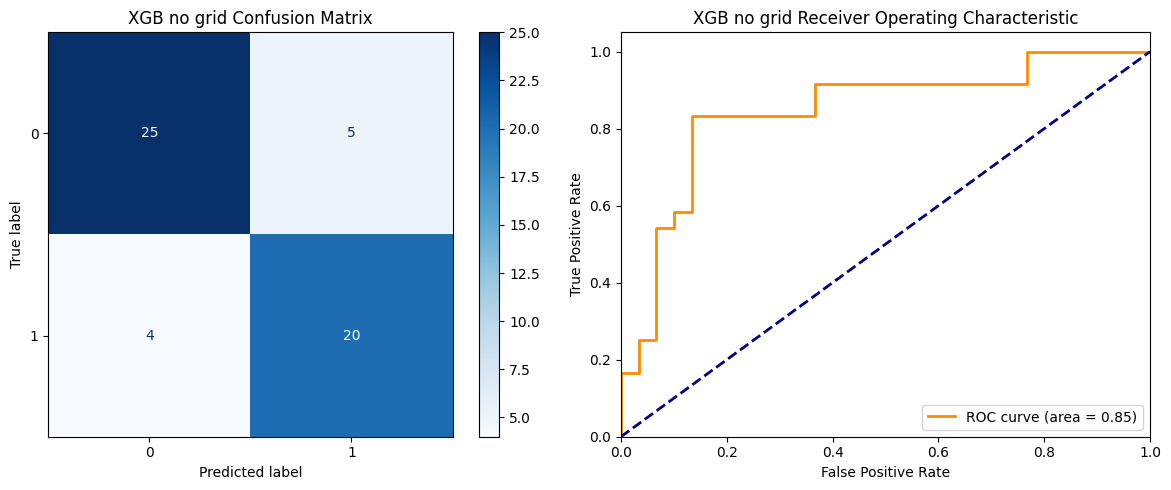

In [19]:
# TODO: build an XGBClassifier and wrap it in a Pipeline with pre
# Hint: start with n_estimators around 300, learning_rate 0.1, max_depth 3 to 5
pipe_xgb = Pipeline(steps=[
    ('preprocessor', pre),
    ('xgb', XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=3,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=RANDOM_STATE
    ))
])
pipe_xgb.fit(X_train, y_train)
xgb_no_metrics = eval_and_report('XGB no grid', pipe_xgb, X_test, y_test)

## Exercise 7 - XGBoost with Grid Search

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:20:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params: {'xgb__colsample_bytree': 0.7, 'xgb__learning_rate': 0.2, 'xgb__max_depth': 3, 'xgb__n_estimators': 100, 'xgb__subsample': 0.7}

--- XGB grid Metrics ---
Accuracy: 0.7963
Precision: 0.7407
Recall: 0.8333
F1: 0.7843


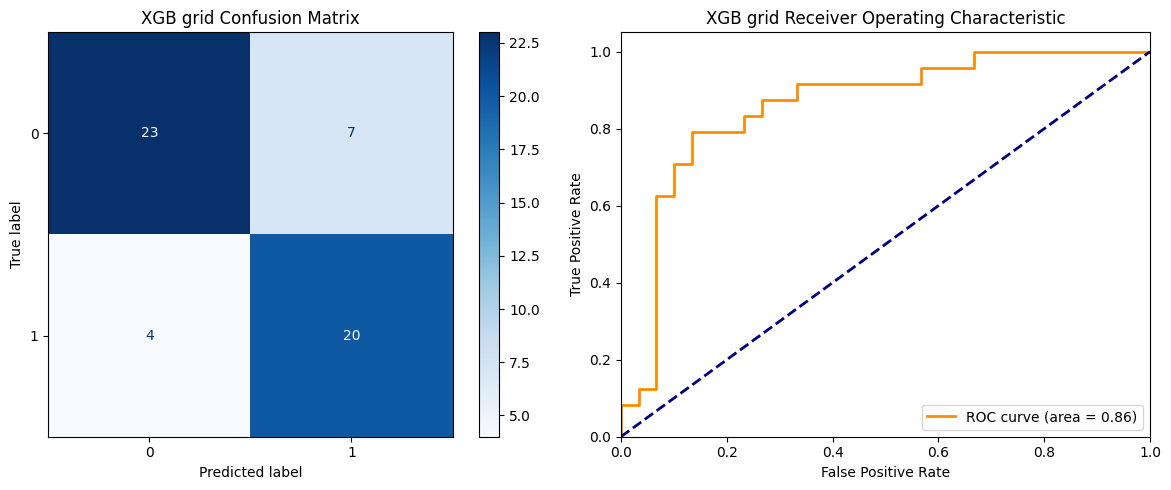

In [20]:
# TODO: Pipeline with XGBClassifier
pipe_xgb_cv = Pipeline(steps=[
    ('preprocessor', pre),
    ('xgb', XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=RANDOM_STATE
    ))
])

# TODO: define a reasonable param_grid
xgb_param_grid = {
    'xgb__n_estimators': [100, 200, 300],
    'xgb__learning_rate': [0.01, 0.1, 0.2],
    'xgb__max_depth': [3, 5, 7],
    'xgb__subsample': [0.7, 0.8, 1.0],
    'xgb__colsample_bytree': [0.7, 0.8, 1.0],
}

# TODO: GridSearchCV, fit, evaluate best estimator
grid_xgb = GridSearchCV(pipe_xgb_cv, xgb_param_grid, cv=5, scoring='f1', verbose=1, n_jobs=-1)
grid_xgb.fit(X_train, y_train)
print('Best params:', grid_xgb.best_params_)
best_xgb = grid_xgb.best_estimator_
xgb_gs_metrics = eval_and_report('XGB grid', best_xgb, X_test, y_test)

## Compare models

In [21]:
# TODO: build a comparison DataFrame from your metrics dicts
# Hint: pd.DataFrame.from_dict(metrics, orient='index')
summary = {}
summary['LR no grid'] = lr_no_gs_metrics
summary['LR grid'] = lr_gs_metrics
summary['SVM no grid'] = svm_no_metrics
summary['SVM grid'] = svm_gs_metrics
summary['XGB no grid'] = xgb_no_metrics
summary['XGB grid'] = xgb_gs_metrics

summary_df = pd.DataFrame.from_dict(summary, orient='index')
summary_df.index.name = 'Model'
print(summary_df)


             accuracy  precision    recall        f1
Model                                               
LR no grid   0.870370   0.814815  0.916667  0.862745
LR grid      0.870370   0.814815  0.916667  0.862745
SVM no grid  0.851852   0.785714  0.916667  0.846154
SVM grid     0.851852   0.785714  0.916667  0.846154
XGB no grid  0.833333   0.800000  0.833333  0.816327
XGB grid     0.796296   0.740741  0.833333  0.784314
